# Squeezing project migration scaffold

This notebook will be the Python driver for the MATLAB Squeezing project.

Planned structure:
1. Define physical parameters and initial state.
2. Port the propensity function from `QD.m`.
3. Port the SSA engine from `directMethod.m`.
4. Add analysis and plots for photon statistics and `g20`.
5. Validate the Python results against the MATLAB outputs.

In [1]:
from pathlib import Path
import sys

import numpy as np

module_dir = Path.cwd()
if not (module_dir / "qd_model.py").exists():
    module_dir = Path.cwd() / "Squeezing_python"
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

from qd_model import Params, qdlaser
from direct_method import direct_method
from direct_method_quiet import direct_method_quiet
from analysis import photon_metrics, g20


params = Params()


In [3]:
stoich_matrix = np.array(
    [
        [1, 0, 0, 0, 0],
        [1, -1, 0, 0, 0],
        [-1, 1, 0, 0, 0],
        [-1, 0, 0, 0, 0],
        [0, 1, -1, 0, 0],
        [0, -1, 1, 0, 0],
        [0, -1, 0, 0, 0],
        [0, 0, -1, 1, 0],
        [0, 0, -1, 0, 0],
        [0, 0, 0, -1, 0],
        [0, 0, 0, -1, 1],
        [0, 0, 0, 1, 0],
    ],
    dtype=float,
)

tspan = (0.0, 5e-8)
x0 = np.array([7.07e5, 6.08e6, 1.1825e7, 3.27e5, 3.3e4], dtype=float)

# Next notebook cell: run `direct_method` with `qdlaser`, then feed the result into `photon_metrics`.


In [4]:
t, x, b = direct_method(
    stoich_matrix=stoich_matrix,
    propensity_fcn=qdlaser,
    tspan=tspan,
    x0=x0,
    params=params,
)

metrics = photon_metrics(x)

print(f"steps: {len(t)}")
print(f"mean photon: {metrics.mean_photon:.6g}")
print(f"g20 in: {metrics.g20_in:.6g}")
print(f"g20 out: {metrics.g20_out:.6g}")


steps: 100001
mean photon: 356.814
g20 in: 678.496
g20 out: 678.242


Validation summary
Python mean photon: 356.814
Python variance: 8.62566e+07
Python g20 in: 678.496
Python g20 out: 678.242
MATLAB reference loaded.


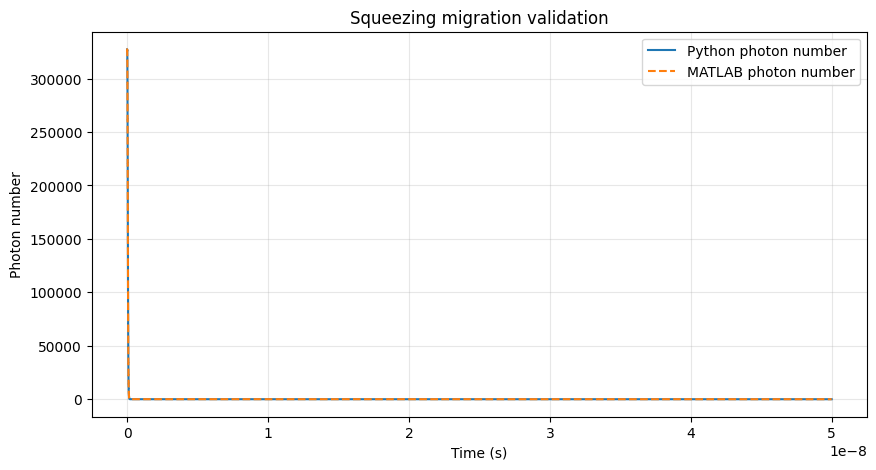

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt

try:
    from scipy.io import loadmat
except ImportError:
    loadmat = None


def load_matlab_reference(mat_path: str):
    if loadmat is None:
        return None, "scipy.io.loadmat is unavailable"
    candidate = Path(mat_path)
    if not candidate.exists():
        return None, f"file not found: {candidate}"
    try:
        return loadmat(candidate, squeeze_me=True, struct_as_record=False), None
    except NotImplementedError as exc:
        return None, str(exc)


reference_path = r"C:\Users\au617810\OneDrive - Aarhus universitet\Videnskabelig assistent\Literature\Articles\Canada\Squeezed theory project\Simulation Codes\Squeezing\exports\squeezing_validation_2.mat"
reference, reference_error = load_matlab_reference(reference_path) if reference_path else (None, None)

fig, ax = plt.subplots(figsize=(10, 5))
ax.step(t, x[:, 3], where="post", label="Python photon number")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Photon number")
ax.set_title("Squeezing migration validation")
ax.legend()
ax.grid(True, alpha=0.3)

if reference is not None:
    matlab_time = np.asarray(reference.get("t", []), dtype=float).ravel()
    matlab_photon = np.asarray(reference.get("x", []), dtype=float)
    if matlab_photon.ndim == 2 and matlab_photon.shape[1] >= 4:
        ax.step(matlab_time, matlab_photon[:, 3], where="post", linestyle="--", label="MATLAB photon number")
        ax.legend()

print("Validation summary")
print(f"Python mean photon: {metrics.mean_photon:.6g}")
print(f"Python variance: {metrics.var_photon:.6g}")
print(f"Python g20 in: {metrics.g20_in:.6g}")
print(f"Python g20 out: {metrics.g20_out:.6g}")
if reference is None:
    print(f"MATLAB reference not loaded: {reference_error}")
    print("If the file was saved with -v7.3, regenerate it without -v7.3 or export plain arrays for scipy.io.loadmat.")
else:
    print("MATLAB reference loaded.")

## Validation

This section compares the migrated Python notebook against MATLAB-style reference data when available.

Checks included here:
- photon-number time trace
- summary metrics such as mean, variance, and `g20`
- optional overlay against a MATLAB `.mat` export

## Additional diagnostics

These cells reproduce the commented-out MATLAB analysis in a simpler Python form.

The goal is to keep the checks separate:
- photon time trace and basic summary statistics
- output-photon increment statistics
- an optional spectrum view for intensity noise

Photon summary
mean photon = 356.814
variance photon = 8.62566e+07
mean NRS = 14172.3
mean NES = 261222
mean NGS = 2.34736e+06


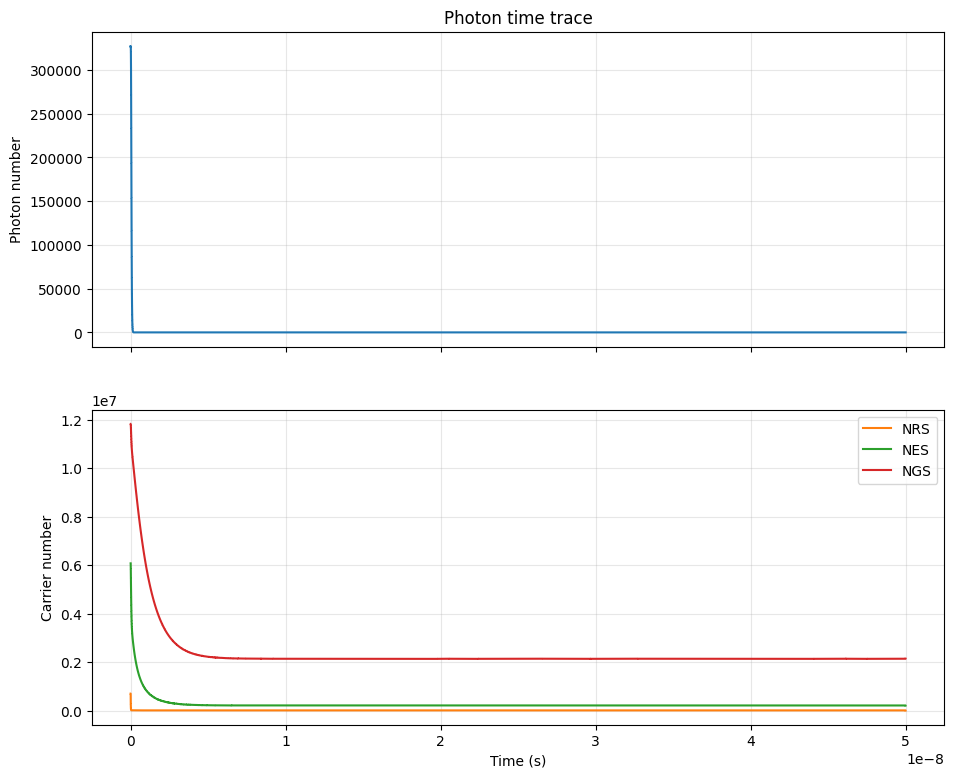

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

axes[0].step(t, x[:, 3], where="post", color="tab:blue", linewidth=1.5)
axes[0].set_ylabel("Photon number")
axes[0].set_title("Photon time trace")
axes[0].grid(True, alpha=0.3)

axes[1].step(t, x[:, 0], where="post", color="tab:orange", label="NRS")
axes[1].step(t, x[:, 1], where="post", color="tab:green", label="NES")
axes[1].step(t, x[:, 2], where="post", color="tab:red", label="NGS")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Carrier number")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

print("Photon summary")
print(f"mean photon = {metrics.mean_photon:.6g}")
print(f"variance photon = {metrics.var_photon:.6g}")
print(f"mean NRS = {metrics.mean_nrs:.6g}")
print(f"mean NES = {metrics.mean_nes:.6g}")
print(f"mean NGS = {metrics.mean_ngs:.6g}")

### Output photon increments

This reproduces the MATLAB `diff(A)` analysis with a cleaner split between the time series and the histogram.

Output increment summary
mean_out = 36.2501
var_out = 889978
ANS = 889941
Fano_out = 24551.1
QM_out = 24550.1
g20_out = 678.242


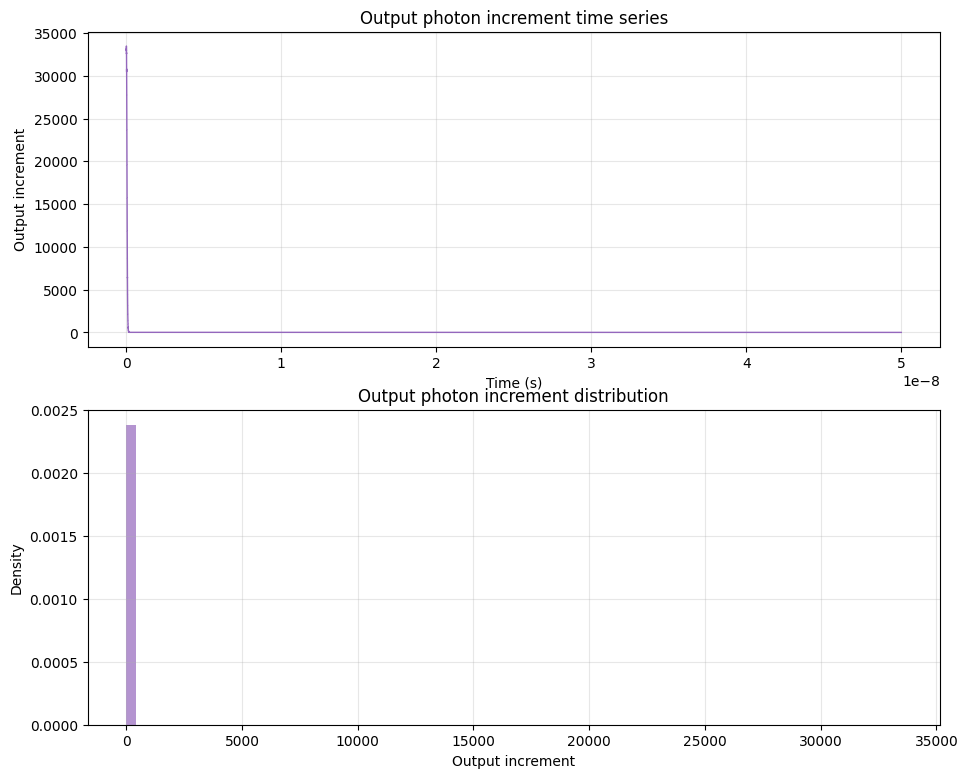

In [12]:
output = x[:, 4]
output_increments = np.diff(output)
if output_increments.size > 0:
    output_increments = output_increments[:-1]

mean_out = float(np.mean(output_increments)) if output_increments.size else float("nan")
var_out = float(np.var(output_increments)) if output_increments.size else float("nan")
ans = float(var_out - mean_out) if output_increments.size else float("nan")
fano_out = float(var_out / mean_out) if output_increments.size and mean_out != 0 else float("nan")
qm_out = float(fano_out - 1) if np.isfinite(fano_out) else float("nan")
g20_out = float(np.mean(output_increments * (output_increments - 1)) / mean_out**2) if output_increments.size and mean_out != 0 else float("nan")

fig, axes = plt.subplots(2, 1, figsize=(11, 9))
axes[0].step(t[2 : 2 + len(output_increments)], output_increments, where="post", color="tab:purple", linewidth=1)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Output increment")
axes[0].set_title("Output photon increment time series")
axes[0].grid(True, alpha=0.3)

if output_increments.size:
    bins = min(80, max(10, int(np.sqrt(output_increments.size))))
    axes[1].hist(output_increments, bins=bins, density=True, color="tab:purple", alpha=0.7)
axes[1].set_xlabel("Output increment")
axes[1].set_ylabel("Density")
axes[1].set_title("Output photon increment distribution")
axes[1].grid(True, alpha=0.3)

print("Output increment summary")
print(f"mean_out = {mean_out:.6g}")
print(f"var_out = {var_out:.6g}")
print(f"ANS = {ans:.6g}")
print(f"Fano_out = {fano_out:.6g}")
print(f"QM_out = {qm_out:.6g}")
print(f"g20_out = {g20_out:.6g}")

### Optional spectral view

This mirrors the MATLAB RIN-style plot, but it is left optional because it is sensitive to sampling length and smoothing choices.

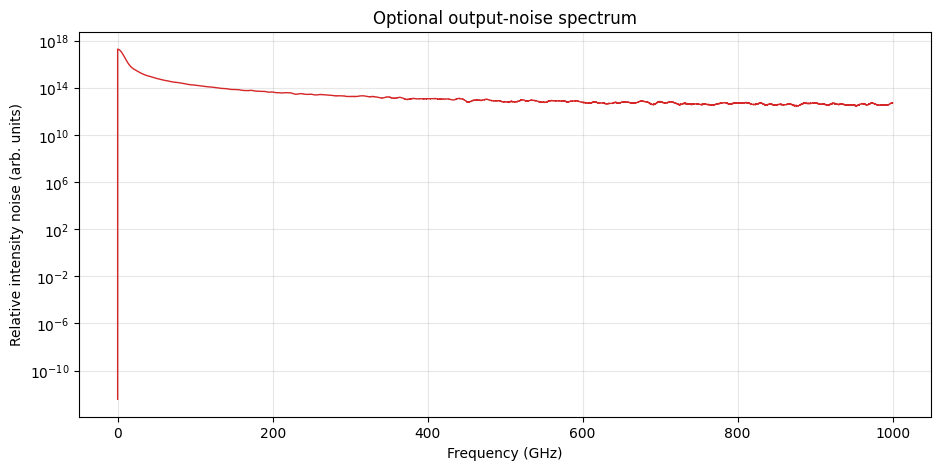

In [13]:
dt = float(params.dt)
fs = 1.0 / dt
centered_output = output_increments - np.mean(output_increments) if output_increments.size else output_increments

if centered_output.size:
    spectrum = np.fft.rfft(centered_output)
    freq = np.fft.rfftfreq(centered_output.size, d=dt)
    rin = (np.abs(spectrum) ** 2) / (centered_output.size * dt * max(mean_out**2, 1e-30))

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.semilogy(freq / 1e9, rin, color="tab:red", linewidth=1)
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Relative intensity noise (arb. units)")
    ax.set_title("Optional output-noise spectrum")
    ax.grid(True, alpha=0.3)
else:
    print("Not enough samples to compute a spectrum.")